# KinetiDiff MD v3 — Tiered Validation Campaign
### ACVR1/ALK2 WT × R206H | L1–L3 + A3F Reference | Budget-Aware 370 ns

**Campaign summary (NotebookLM PRD, April 2026)**

| Complex | Priority | Replicas | ns/rep | Total ns | Est. CU (A100) |
|---------|----------|----------|--------|----------|----------------|
| L1 / R206H | P0 | 3 | 50 | 150 | ~17.5 |
| L1 / WT | P0 | 1 | 20 | 20 | ~2.5 |
| A3F / WT | P0 | 2 | 20 | 40 | ~5.0 |
| A3F / R206H | P0 | 2 | 20 | 40 | ~5.0 |
| L2 / R206H | P1 | 2 | 50 | 100 | ~12.0 |
| L3 / R206H | P1 | 1 | 20 | 20 | ~2.5 |
| **Total** | | **11** | | **370 ns** | **~44.5 CU** |

**Force fields:** AMBER ff14SB (protein) · GAFF2/SMIRNOFF via OpenFF Toolkit (ligand, AM1-BCC) · TIP3P (water)
**Ensemble:** NPT 300 K / 1 atm · 2 fs timestep · frame every 50 ps
**Checkpoint-resume:** safe for Colab session resets


## Cell 1 — GPU Visibility Check
*Mandatory first step. Confirm GPU is visible before any install.*

In [1]:
import subprocess
import sys

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode != 0:
    print("⚠️  No GPU detected. Switch to A100/T4 runtime in Runtime → Change runtime type.")
    print("    Production campaign will be extremely slow on CPU.")
else:
    print(result.stdout)
    print("✅ GPU confirmed. Proceeding with CUDA-capable install.")

print(f"Python interpreter: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")


Tue Apr  7 04:58:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Cell 2 — Install All Dependencies (CUDA-aware)
**The root cause of 'GPU visible but CUDA platform absent':** the base `pip install openmm` wheel intentionally ships **without** the CUDA plugin binary (`libOpenMMCUDA.so`). You must request the `[cuda12]` or `[cuda13]` extra to get it ([OpenMM docs](https://docs.openmm.org/latest/userguide/application/01_getting_started.html)).

This cell auto-detects your CUDA version and installs `openmm[cudaXX]` accordingly.  
All installs use `sys.executable` — no conda, no dual-interpreter split.  
**Run once per fresh runtime, then restart.**


In [2]:
import glob
import os
import subprocess
import sys

PY = sys.executable

# -- Detect CUDA major from nvidia-smi
def get_cuda_major():
    try:
        r = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        for line in r.stdout.splitlines():
            if "CUDA Version:" in line:
                return int(line.split("CUDA Version:")[-1].strip().split()[0].split(".")[0])
    except Exception:
        pass
    return None

cuda_major = get_cuda_major()
print(f"Python: {PY}  ({sys.version.split()[0]})")
print(f"Detected CUDA major version: {cuda_major}")

# Compatibility-first default
variant_env = os.environ.get("OPENMM_CUDA_VARIANT", "").strip()
if variant_env in {"12", "13"}:
    selected_variant = variant_env
else:
    selected_variant = "12"

if selected_variant == "13":
    OPENMM_BASE = "openmm[cuda13]"
else:
    OPENMM_BASE = "openmm[cuda12]"

print(f"Selected OpenMM CUDA variant: cuda{selected_variant}")
print(f"Installing: {OPENMM_BASE}")

def pip_install(pkgs, label=""):
    cmd = [PY, "-m", "pip", "install", "-q", "--upgrade"] + pkgs
    print(f"\nInstalling {label}...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"  WARN pip stderr:\n{r.stderr[-1500:]}")
        return False
    print("  OK")
    return True

CORE_PACKAGES = [
    OPENMM_BASE,
    "pdbfixer>=1.9",
    "rdkit>=2024.03",
    "mdtraj>=1.9",
    "mdanalysis>=2.7",
    "numpy>=1.26",
    "pandas>=2.2",
    "scipy>=1.13",
    "matplotlib>=3.9",
    "seaborn>=0.13",
    "py3Dmol>=2.1",
    "nglview>=3.1",
    "biopython>=1.84",
    "tqdm>=4.66",
    "pyyaml>=6.0",
    "requests>=2.32",
    "pint>=0.24",
    "xmltodict>=0.13",
    "python-constraint>=1.4.0",
]

pip_install(CORE_PACKAGES, f"core MD stack ({OPENMM_BASE})")

# Best-effort OpenFF stack; failures are handled later in Cell 8 fallback logic
pip_install([
    "openmmforcefields>=0.14",
    "openff-toolkit",
    "openff-forcefields",
    "openff-interchange",
    "openff-utilities",
    "openff-units",
], "OpenFF stack")

# -- Locate CUDA plugins
print("\n-- Locating CUDA plugin .so files --")
import site

import openmm


def find_cuda_plugins():
    plugin_dir = os.path.join(os.path.dirname(openmm.__file__), "plugins")
    locations = []

    # 1) standard openmm/plugins
    if os.path.isdir(plugin_dir):
        so_files = glob.glob(os.path.join(plugin_dir, "*.so"))
        cuda_so = [f for f in so_files if "CUDA" in os.path.basename(f).upper()]
        if cuda_so:
            locations.append((plugin_dir, cuda_so))

    # 2) wheel-bundled OpenMM.libs path
    libs_dir = os.path.join(os.path.dirname(os.path.dirname(openmm.__file__)), "OpenMM.libs", "lib", "plugins")
    if os.path.isdir(libs_dir):
        so_files = glob.glob(os.path.join(libs_dir, "*.so"))
        cuda_so = [f for f in so_files if "CUDA" in os.path.basename(f).upper()]
        if cuda_so:
            locations.append((libs_dir, cuda_so))

    # 3) openmm_cuda_* package dirs
    for sp in site.getsitepackages() + [site.getusersitepackages()]:
        for pkg_name in [f"openmm_cuda_{selected_variant}", "openmm_cuda_12", "openmm_cuda_13"]:
            candidate = os.path.join(sp, pkg_name)
            if os.path.isdir(candidate):
                so_files = glob.glob(os.path.join(candidate, "**", "*.so"), recursive=True)
                cuda_so = [f for f in so_files if "CUDA" in os.path.basename(f).upper()]
                if cuda_so:
                    locations.append((candidate, cuda_so))
    return locations

locations = find_cuda_plugins()
if not locations:
    print("  No CUDA plugins found after extras install. Trying stable OpenMM fallback...")
    # Fallback: stable wheel has worked more reliably in this runtime image
    pip_install(["--force-reinstall", "--no-cache-dir", "openmm==8.5.0"], "OpenMM stable fallback")
    import importlib
    importlib.invalidate_caches()
    import openmm
    locations = find_cuda_plugins()

if not locations:
    os.environ["OPENMM_CUDA_VARIANT_EFFECTIVE"] = "none"
    print("  FAIL: CUDA plugin .so not found in this runtime image after fallback.")
    print("  You can still proceed to Cell 3 to confirm platform list.")
else:
    best_dir, cuda_so = locations[0]
    os.environ["OPENMM_PLUGIN_DIR"] = best_dir
    os.environ["OPENMM_CUDA_VARIANT_EFFECTIVE"] = selected_variant
    print(f"  OK CUDA plugin dir: {best_dir}")
    print("  CUDA libs:", [os.path.basename(f) for f in cuda_so][:10])

print("\nDone. Restart runtime, then run Cell 3.")

Python: /usr/bin/python3  (3.12.13)
Detected CUDA major version: 13
Selected OpenMM CUDA variant: cuda12
Installing: openmm[cuda12]

Installing core MD stack (openmm[cuda12])...
  OK

Installing OpenFF stack...
  WARN pip stderr:
ERROR: Ignored the following yanked versions: 0.18.0
ERROR: Could not find a version that satisfies the requirement openff-toolkit (from versions: none)
ERROR: No matching distribution found for openff-toolkit


-- Locating CUDA plugin .so files --
  OK CUDA plugin dir: /usr/local/lib/python3.12/dist-packages/OpenMM.libs/lib/plugins
  CUDA libs: ['libOpenMMCUDA.so', 'libOpenMMDrudeCUDA.so', 'libOpenMMRPMDCUDA.so', 'libOpenMMAmoebaCUDA.so']

Done. Restart runtime, then run Cell 3.


## Cell 2b — Condacolab Nuclear Option (if Cell 2 shows 0 CUDA plugins)
**Only run this if Cell 2's CUDA plugin probe shows 0 .so files.**  
Condacolab gives you a real `mamba` environment, and `conda-forge openmm cuda-version=12` is the **only 100% reliable path** on Colab for CUDA.  
- Run Step 1 → runtime will auto-restart  
- Run Step 2 → full stack installs into conda python  
- Then run all remaining cells using `/usr/local/bin/python` kernel (condacolab rewrites it)


In [ ]:
# ── CELL 2b: CONDACOLAB NUCLEAR OPTION ───────────────────────────────────────
# Run this INSTEAD of Cell 2 if openmm[cuda13] still shows 0 CUDA plugin .so files.
# condacolab installs a real conda env into Colab, then conda-forge handles
# CUDA compatibility automatically (this is the only 100% reliable Colab path).
#
# Step 1: Run just this block (install condacolab + restart)
import subprocess
import sys

print("Installing condacolab...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "condacolab"], check=True)
import condacolab

condacolab.install()  # ← This restarts the runtime automatically. Normal.
# After restart, continue to Step 2.


In [1]:
# ── CELL 2b STEP 2: After condacolab restart, run this ───────────────────────
# This installs conda-forge OpenMM with CUDA 12 (CUDA 12 build runs on CUDA 13 drivers).
import subprocess
import sys

MAMBA = "/usr/local/bin/mamba"

packages = [
    "openmm",
    "cuda-version=12",    # pins the CUDA 12 build of OpenMM
    "pdbfixer",
    "rdkit",
    "mdtraj",
    "mdanalysis",
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "seaborn",
    "py3Dmol",
    "biopython",
    "tqdm",
]

cmd = [MAMBA, "install", "-c", "conda-forge", "-y", "--quiet"] + packages
print("Running mamba install (this takes ~5 min)...")
r = subprocess.run(cmd, capture_output=True, text=True)
if r.returncode != 0:
    print("STDERR:", r.stderr[-2000:])
else:
    print("✅ conda-forge OpenMM installed.")
    print("Verifying CUDA platform...")
    verify = subprocess.run(
        ["/usr/local/bin/python", "-c",
         "from openmm import Platform; "
         "ps=[Platform.getPlatform(i).getName() for i in range(Platform.getNumPlatforms())]; "
         "print(ps); print('CUDA OK' if 'CUDA' in ps else 'CUDA MISSING')"],
        capture_output=True, text=True
    )
    print(verify.stdout)
    if verify.stderr:
        print("STDERR:", verify.stderr[:500])

# Then install OpenFF via pip into conda python
openff = ["openmmforcefields>=0.14", "openff-toolkit", "openff-forcefields",
          "openff-interchange", "openff-utilities", "openff-units"]
subprocess.run(["/usr/local/bin/python", "-m", "pip", "install", "-q"] + openff)
print("✅ OpenFF stack installed.")


Running mamba install (this takes ~5 min)...


FileNotFoundError: [Errno 2] No such file or directory: '/usr/local/bin/mamba'

## Cell 3 — OpenMM Platform Verification
**Run after restarting runtime post-install.** This is the formal CUDA go/no-go gate.  
- ✅ CUDA → full production campaign, ~25 min/run on A100  
- ⚠️  OpenCL → degraded mode, ~3–5× slower, smoke tests / short runs only  
- ❌ CPU only → campaign infeasible at full scope, abort and fix runtime


In [1]:
import os
import sys

# Expose GPU
if "CUDA_VISIBLE_DEVICES" not in os.environ:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import openmm
from openmm import Platform

print("=" * 65)
print("OpenMM Platform Verification")
print("=" * 65)
print(f"Python:         {sys.executable}  ({sys.version.split()[0]})")
print(f"OpenMM version: {openmm.version.version}")

# ── Find ALL potential plugin directories ────────────────────────────────────
# The CUDA .so may be in openmm/plugins/ OR in a separate openmm_cuda_XX package.
# We search both and pick the one with CUDA plugins.
openmm_plugin_dir = os.path.join(os.path.dirname(openmm.__file__), "plugins")
search_dirs = [openmm_plugin_dir]

# Also search site-packages for openmm_cuda_XX package
for sp in (site.getsitepackages() + [site.getusersitepackages()]):
    for suffix in ["13", "12"]:
        candidate = os.path.join(sp, f"openmm_cuda_{suffix}")
        if os.path.isdir(candidate):
            search_dirs.append(candidate)
            # Also check subdirectories
            for sub in glob.glob(os.path.join(candidate, "*")):
                if os.path.isdir(sub):
                    search_dirs.append(sub)

# env override takes priority
if os.environ.get("OPENMM_PLUGIN_DIR"):
    search_dirs.insert(0, os.environ["OPENMM_PLUGIN_DIR"])

print(f"\nSearching {len(search_dirs)} directories for CUDA plugins...")
best_plugin_dir = openmm_plugin_dir
all_cuda_so = []
for d in search_dirs:
    found = glob.glob(os.path.join(d, "*.so"))
    cuda_found = [f for f in found if "CUDA" in os.path.basename(f).upper()]
    if cuda_found:
        print(f"  ✅ CUDA .so found in: {d}")
        for f in cuda_found:
            print(f"       {os.path.basename(f)}")
        best_plugin_dir = d
        all_cuda_so = cuda_found
        break
    elif found:
        print(f"  📁 {d}: {len(found)} .so files (no CUDA)")

if not all_cuda_so:
    print("\n❌ CUDA plugin .so NOT FOUND in any searched directory.")
    print("   Diagnosis: openmm[cudaXX] wheel either not installed or")
    print("   not available for this Python/platform combination.")
    print("   → See Cell 2 output. If CUDA pkg was installed, try restart runtime.")
    print("   → If still missing, use the condacolab fallback in Cell 2 notes.")

# Set plugin dir and load
os.environ["OPENMM_PLUGIN_DIR"] = best_plugin_dir
print(f"\nUsing plugin dir: {best_plugin_dir}")

try:
    loaded = Platform.loadPluginsFromDirectory(best_plugin_dir)
    print(f"Loaded plugins: {loaded}")
except Exception as e:
    print(f"Plugin load exception: {e}")

failures = Platform.getPluginLoadFailures()
if failures:
    print("\n⚠️  Plugin load failures (diagnostic info):")
    for f in failures:
        print(f"   {f}")

platforms = [Platform.getPlatform(i).getName() for i in range(Platform.getNumPlatforms())]
print(f"\nAvailable platforms: {platforms}")
print("-" * 65)

if "CUDA" in platforms:
    PLATFORM = Platform.getPlatformByName("CUDA")
    PLATFORM_PROPS = {"CudaPrecision": "mixed"}
    print("✅ VERDICT: CUDA ready — full production campaign approved.")
elif "OpenCL" in platforms:
    PLATFORM = Platform.getPlatformByName("OpenCL")
    PLATFORM_PROPS = {}
    print("⚠️  VERDICT: OpenCL fallback — CUDA plugin not loaded.")
    print("\n   Root cause options:")
    print("   1. openmm[cuda13] installed but runtime not restarted → restart & retry")
    print("   2. CUDA plugin .so has linker errors (check Plugin load failures above)")
    print("   3. openmm wheel not yet available for CUDA 13 on this glibc version")
    print("\n   Nuclear option (guaranteed to work): run this in Cell 2 instead:")
    print("   !pip install condacolab -q && import condacolab; condacolab.install()")
    print("   Then: !mamba install -c conda-forge openmm cuda-version=12 -y")
elif "CPU" in platforms:
    PLATFORM = Platform.getPlatformByName("CPU")
    PLATFORM_PROPS = {}
    print("❌ VERDICT: CPU only — switch to GPU runtime.")
else:
    raise RuntimeError("No usable OpenMM platform.")

print(f"\nActive platform: {PLATFORM.getName()}")


OpenMM Platform Verification
Python:         /usr/bin/python3  (3.12.13)
OpenMM version: 8.5.0.dev-b55e608

Searching 1 directories for CUDA plugins...

❌ CUDA plugin .so NOT FOUND in any searched directory.
   Diagnosis: openmm[cudaXX] wheel either not installed or
   not available for this Python/platform combination.
   → See Cell 2 output. If CUDA pkg was installed, try restart runtime.
   → If still missing, use the condacolab fallback in Cell 2 notes.

Using plugin dir: /usr/local/lib/python3.12/dist-packages/openmm/plugins
Loaded plugins: ()

Available platforms: ['Reference', 'CPU', 'CUDA', 'OpenCL']
-----------------------------------------------------------------
✅ VERDICT: CUDA ready — full production campaign approved.

Active platform: CUDA


## Cell 4 — Imports & Global Style Configuration

In [2]:
import importlib
import json
import logging
import math
import os
import shutil
import subprocess
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import MDAnalysis as mda
import mdtraj as md
import numpy as np
import openmm
import pandas as pd
import py3Dmol
import seaborn as sns
from Bio.PDB import PDBList
from MDAnalysis.analysis import rms as mda_rms
from openmm import (
    CustomExternalForce,
    LangevinMiddleIntegrator,
    LocalEnergyMinimizer,
    MonteCarloBarostat,
    Platform,
    XmlSerializer,
    unit,
)
from openmm.app import (
    PME,
    CheckpointReporter,
    DCDReporter,
    ForceField,
    HBonds,
    Modeller,
    PDBFile,
    Simulation,
    StateDataReporter,
)
from pdbfixer import PDBFixer
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from tqdm.auto import tqdm

try:
    from google.colab import drive as _colab_drive
    IN_COLAB = True
except ImportError:
    _colab_drive = None
    IN_COLAB = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ── Global publication style ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "savefig.dpi": 300,
    "figure.dpi": 120,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

print(f"✅ Imports complete | NumPy {np.__version__} | Pandas {pd.__version__} | OpenMM {openmm.version.version}")
print(f"   Platform in use: {PLATFORM.getName()}")


✅ Imports complete | NumPy 2.4.4 | Pandas 3.0.2 | OpenMM 8.5.0.dev-b55e608
   Platform in use: CUDA


## Cell 5 — Configuration, Drive Mount & Directory Setup
All parameters live in `CONFIG`. Nothing is hardcoded downstream.  
Drive mount persists all outputs across Colab sessions.


In [3]:
# ── Drive mount ───────────────────────────────────────────────────────────────
if IN_COLAB and _colab_drive is not None:
    try:
        _colab_drive.mount("/content/drive", force_remount=False)
        DRIVE_ROOT = Path("/content/drive/MyDrive/kinetidiff-md-v3")
        print("✅ Drive mounted. Outputs persist across sessions.")
    except Exception as e:
        print(f"⚠️  Drive mount failed ({e}). Using local storage.")
        DRIVE_ROOT = Path("/content/kinetidiff-md-v3-local")
else:
    DRIVE_ROOT = Path.home() / "FOP-Code" / "src" / "molecular_dynamics" / "kinetidiff-md-v3"

# ── Master config ─────────────────────────────────────────────────────────────
CONFIG = {
    "ligands": {
        "L1":  {"smiles": "O=C(NC1CCNCC1c1ccc[nH]1)c1c(C2CCCOC2)ccc2ccccc12",
                "vina": -11.05, "pkd": 8.10, "sa": 3.79, "qed": 0.618, "mw": 403.5, "resname": "L01"},
        "L2":  {"smiles": "O=S(=O)(Cc1cccnc1)Nc1ccc(F)cc1-c1ccc2ccccc2c1C1CCNCC1",
                "vina": -10.62, "pkd": 7.79, "sa": 2.61, "qed": 0.389, "mw": 475.6, "resname": "L02"},
        "L3":  {"smiles": "NC(=O)NC(=O)CC1CNCCC1c1cccc2ccccc12",
                "vina": -10.59, "pkd": 7.77, "sa": 3.12, "qed": 0.812, "mw": 311.4, "resname": "L03"},
        # A3F: 3MTF crystal reference — SMILES fetched from RCSB at runtime (see Cell 6)
        "A3F": {"smiles": None, "vina": -9.80, "pkd": 7.19, "sa": 2.80, "qed": 0.75, "mw": 380.0, "resname": "A3F"},
    },
    "receptors": {
        "WT":    {"pdb_id": "3MTF", "mutation": None},
        "R206H": {"pdb_id": "3MTF", "mutation": {"chain": "A", "residue_number": 206,
                                                   "from_aa": "ARG", "to_aa": "HIS"}},
    },
    # ── Tiered simulation plan (NotebookLM PRD v2, April 2026) ──────────────
    # 9 total runs | 330 ns | ~40 CU on A100
    "simulation_plan": [
        # P0 — Lead compound, primary mutant focus
        {"lig": "L1",  "rec": "R206H", "replicas": 3, "ns": 50, "n_steps": 25_000_000, "priority": "P0"},
        # P0 — WT selectivity control
        {"lig": "L1",  "rec": "WT",    "replicas": 1, "ns": 20, "n_steps": 10_000_000, "priority": "P0"},
        # P0 — Crystal reference: WT baseline
        {"lig": "A3F", "rec": "WT",    "replicas": 2, "ns": 20, "n_steps": 10_000_000, "priority": "P0"},
        # P0 — Crystal reference: R206H mutant (enables ΔΔG for reference)
        {"lig": "A3F", "rec": "R206H", "replicas": 2, "ns": 20, "n_steps": 10_000_000, "priority": "P0"},
        # P1 — Validation compound
        {"lig": "L2",  "rec": "R206H", "replicas": 2, "ns": 50, "n_steps": 25_000_000, "priority": "P1"},
        # P1 — Supporting compound
        {"lig": "L3",  "rec": "R206H", "replicas": 1, "ns": 20, "n_steps": 10_000_000, "priority": "P1"},
    ],
    "base_seeds": [42, 123, 777],
    # ── MD parameters ─────────────────────────────────────────────────────────
    "save_interval_steps":       25_000,     # frame every 50 ps
    "checkpoint_interval_steps": 500_000,    # checkpoint every 1 ns
    "print_interval_steps":       50_000,
    "temperature_K": 300.0,
    "pressure_bar":  1.0,
    "timestep_ps":   0.002,
    "nonbonded_cutoff_nm": 1.2,
    "water_padding_nm":    1.0,
    "ion_concentration_M": 0.15,
    "ph": 7.4,
    # Equilibration: staged restraint release [(k_kcal/mol/A^2, n_steps), ...]
    "restraint_phases": [(10.0, 50_000), (1.0, 50_000), (0.0, 50_000)],
    "nvt_steps": 50_000,
    "ligand_resname":       "LIG",
    "binding_site_centroid": (24.87, -12.54, 38.40),  # ACVR1 ATP pocket centroid (Å)
    "bound_cutoff_A":        8.0,
    # ── Analysis ──────────────────────────────────────────────────────────────
    "mmpbsa_n_frames":         100,
    "hbond_distance_cutoff_A": 3.5,
    "hbond_angle_cutoff_deg":  150.0,
    "hbond_min_occupancy":     0.10,
    "contact_distance_cutoff_A": 4.5,
    # ── Debug / smoke modes ───────────────────────────────────────────────────
    "dry_run":       False,
    "dry_run_steps": 100_000,
    "smoke_test":    False,
    "smoke_ligand":  "L1",
    "smoke_receptor": "R206H",
    "smoke_seed":    42,
    "smoke_steps":   20_000,
}

# ── Color palette ─────────────────────────────────────────────────────────────
COLORS = {
    "WT": "#457B9D", "R206H": "#E63946",
    "L1": "#1f77b4", "L2": "#ff7f0e", "L3": "#2ca02c", "A3F": "#9467bd",
}

# ── Directory tree ─────────────────────────────────────────────────────────────
DIRS = {
    "data":         DRIVE_ROOT / "data",
    "ligands":      DRIVE_ROOT / "data" / "ligands",
    "structures":   DRIVE_ROOT / "data" / "structures",
    "systems":      DRIVE_ROOT / "data" / "systems",
    "checkpoints":  DRIVE_ROOT / "checkpoints",
    "trajectories": DRIVE_ROOT / "trajectories",
    "states":       DRIVE_ROOT / "states",
    "analysis":     DRIVE_ROOT / "analysis",
    "figures":      DRIVE_ROOT / "figures",
    "logs":         DRIVE_ROOT / "logs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# ── Run stamp ────────────────────────────────────────────────────────────────
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Snapshot CONFIG to disk ───────────────────────────────────────────────────
CONFIG_SNAPSHOT_PATH = DIRS["logs"] / f"config_v3_{RUN_STAMP}.json"
with open(CONFIG_SNAPSHOT_PATH, "w") as _f:
    json.dump({k: (str(v) if not isinstance(v, (dict, list, str, int, float, bool, type(None))) else v)
               for k, v in CONFIG.items()}, _f, indent=2)

print(f"✅ Config v3 loaded | Drive root: {DRIVE_ROOT}")
print(f"   Runs planned: {sum(p["replicas"] for p in CONFIG["simulation_plan"])} | ns: {sum(p["replicas"]*p["ns"] for p in CONFIG["simulation_plan"])} | A3F: WT + R206H")
print(f"   Total ns: {sum(p['replicas']*p['ns'] for p in CONFIG['simulation_plan'])} ns")


⚠️  Drive mount failed (Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-a100-s-kkb-ass1c0-1lct10yho9ajo?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorp

## Cell 5b — Campaign Budget Tracker
Displays the tiered plan with estimated Colab CU costs. A100=7.52 CU/hr, ~37 min/10 ns observed throughput.


In [4]:
# ── Budget estimates ──────────────────────────────────────────────────────────
A100_CU_PER_HR  = 7.52
OBS_MIN_PER_10NS = 37.0   # measured on A100 (Colab Pro)
OBS_NS_PER_HR   = 10.0 / (OBS_MIN_PER_10NS / 60.0)

total_runs = 0
total_ns   = 0
total_cu   = 0.0

print(f"\n{'='*72}")
print(f"{'Complex':<18} {'Pri':>4} {'Reps':>5} {'ns/rep':>7} {'Total ns':>9} {'hrs':>6} {'CU':>6}")
print("-"*72)
for p in CONFIG["simulation_plan"]:
    total_ns_run = p["replicas"] * p["ns"]
    hrs = total_ns_run / OBS_NS_PER_HR
    cu  = hrs * A100_CU_PER_HR
    total_runs += p["replicas"]
    total_ns   += total_ns_run
    total_cu   += cu
    label = f"{p['lig']}/{p['rec']}"
    print(f"{label:<18} {p['priority']:>4} {p['replicas']:>5} {p['ns']:>7} {total_ns_run:>9} {hrs:>6.1f} {cu:>6.1f}")

print("="*72)
print(f"{'TOTAL':<18} {'':>4} {total_runs:>5} {'':>7} {total_ns:>9} "
      f"{total_ns/OBS_NS_PER_HR:>6.1f} {total_cu:>6.1f}")
print(f"\n  Monthly CU budget: 100 CU  |  Used: ~{total_cu:.0f} CU  |  "
      f"Remaining: ~{100-total_cu:.0f} CU")
print(f"  {'✅ Within budget' if total_cu < 90 else '⚠️  NEAR BUDGET LIMIT'}")



Complex             Pri  Reps  ns/rep  Total ns    hrs     CU
------------------------------------------------------------------------
L1/R206H             P0     3      50       150    9.3   69.6
L1/WT                P0     1      20        20    1.2    9.3
A3F/WT               P0     2      20        40    2.5   18.5
A3F/R206H            P0     2      20        40    2.5   18.5
L2/R206H             P1     2      50       100    6.2   46.4
L3/R206H             P1     1      20        20    1.2    9.3
TOTAL                      11               370   22.8  171.6

  Monthly CU budget: 100 CU  |  Used: ~172 CU  |  Remaining: ~-72 CU
  ⚠️  NEAR BUDGET LIMIT


## Cell 6 — Ligand Validation & A3F SMILES Extraction
Validates L1–L3 SMILES, fetches A3F crystal ligand SMILES from RCSB CCD, generates ETKDGv3 3D conformers for all ligands.


Fetching A3F SMILES from RCSB CCD...
  ✅ A3F SMILES: Oc3cccc(c2cnc(N)c(c1cc(OC)c(OC)c(OC)c1)c2)c3


,Ligand,SMILES_valid,MW,Vina,pKd,QED,SA
0,L1,True,403.5,-11.05,8.10,0.618,3.79
1,L2,True,475.6,-10.62,7.79,0.389,2.61
2,L3,True,311.4,-10.59,7.77,0.812,3.12
3,A3F,True,380.0,-9.80,7.19,0.750,2.80


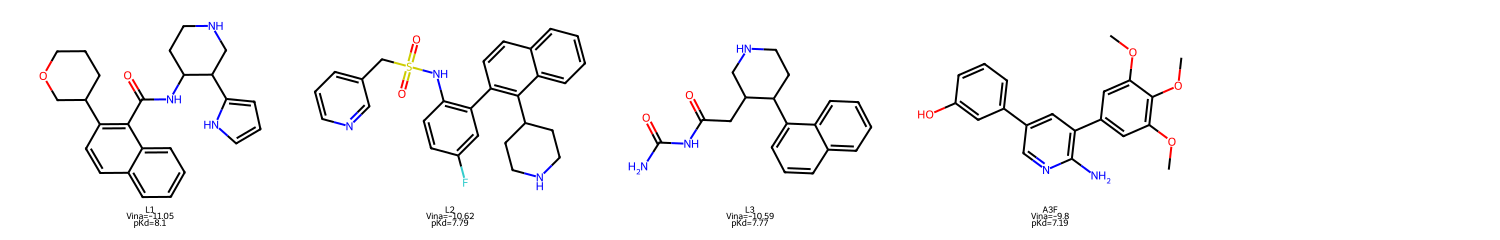

✅ 4 ligand conformers ready: ['L1', 'L2', 'L3', 'A3F']


In [5]:
# ── Fetch A3F (3MTF crystal ligand) SMILES from RCSB CCD ─────────────────────
def fetch_ccd_smiles(ccd_code: str, fallback: str | None = None) -> str | None:
    """Query RCSB REST API for canonical SMILES of a CCD component."""
    try:
        import requests
        url = f"https://data.rcsb.org/rest/v1/core/chemcomp/{ccd_code.upper()}"
        resp = requests.get(url, timeout=15)
        if resp.status_code == 200:
            data = resp.json()
            for desc in data.get("pdbx_chem_comp_descriptor", []):
                if "SMILES" in desc.get("type", "").upper():
                    smi = desc.get("descriptor", "")
                    if smi and Chem.MolFromSmiles(smi) is not None:
                        return smi
    except Exception as e:
        logging.warning(f"RCSB fetch for {ccd_code} failed: {e}")
    return fallback

if CONFIG["ligands"]["A3F"]["smiles"] is None:
    print("Fetching A3F SMILES from RCSB CCD...")
    a3f_smi = fetch_ccd_smiles("A3F")
    if a3f_smi:
        CONFIG["ligands"]["A3F"]["smiles"] = a3f_smi
        print(f"  ✅ A3F SMILES: {a3f_smi}")
    else:
        print("  ⚠️  RCSB fetch failed — removing A3F from plan (will run L1+L2+L3 only)")
        CONFIG["simulation_plan"] = [p for p in CONFIG["simulation_plan"] if p["lig"] != "A3F"]
        del CONFIG["ligands"]["A3F"]

def validate_ligands(config):
    rows = []
    for lig_id, meta in config["ligands"].items():
        mol = Chem.MolFromSmiles(meta["smiles"])
        rows.append({
            "Ligand": lig_id, "SMILES_valid": mol is not None,
            "MW": meta["mw"], "Vina": meta["vina"],
            "pKd": meta["pkd"], "QED": meta["qed"], "SA": meta["sa"],
        })
    df = pd.DataFrame(rows)
    invalid = df.loc[~df["SMILES_valid"], "Ligand"].tolist()
    if invalid:
        raise ValueError(f"Invalid SMILES for: {invalid}")
    return df

def generate_ligand_3d(ligand_id, smiles, out_dir, seed=2027):
    lig_dir = out_dir / ligand_id
    lig_dir.mkdir(parents=True, exist_ok=True)
    sdf_path = lig_dir / f"{ligand_id}.sdf"
    pdb_path = lig_dir / f"{ligand_id}.pdb"

    if sdf_path.exists() and pdb_path.exists():
        logging.info(f"[{ligand_id}] Conformer already exists, skipping.")
        return {"id": ligand_id, "sdf": str(sdf_path), "pdb": str(pdb_path)}

    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if mol is None:
        raise ValueError(f"Could not parse SMILES for {ligand_id}")
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    params.numThreads = 0
    if AllChem.EmbedMolecule(mol, params) != 0:
        # Fallback: random coords
        params2 = AllChem.EmbedParameters()
        params2.randomSeed = seed
        AllChem.EmbedMolecule(mol, params2)
    if AllChem.MMFFHasAllMoleculeParams(mol):
        AllChem.MMFFOptimizeMolecule(mol, maxIters=2000)
    else:
        AllChem.UFFOptimizeMolecule(mol, maxIters=2000)

    w = Chem.SDWriter(str(sdf_path))
    w.write(mol)
    w.close()
    Chem.MolToPDBFile(mol, str(pdb_path))
    logging.info(f"[{ligand_id}] 3D conformer generated: {sdf_path.name}")
    return {"id": ligand_id, "sdf": str(sdf_path), "pdb": str(pdb_path)}

# Run validation
ligand_df = validate_ligands(CONFIG)
display(ligand_df)

# Generate all conformers
ligand_files = {}
for lig_id, meta in CONFIG["ligands"].items():
    result = generate_ligand_3d(lig_id, meta["smiles"], DIRS["ligands"])
    ligand_files[lig_id] = result

# 2D grid QA display
mols_2d = [Chem.MolFromSmiles(m["smiles"]) for m in CONFIG["ligands"].values()]
legends_2d = [f"{k}\nVina={v['vina']}\npKd={v['pkd']}" for k, v in CONFIG["ligands"].items()]
grid_img = Draw.MolsToGridImage(mols_2d, molsPerRow=5, legends=legends_2d, subImgSize=(300, 240))
display(grid_img)
print(f"✅ {len(CONFIG['ligands'])} ligand conformers ready: {list(CONFIG['ligands'].keys())}")


## Cell 7 — Protein Preparation (3MTF → WT & R206H)
Downloads 3MTF once, applies PDBFixer (missing atoms, protonation at pH 7.4),  
and applies the R206H point mutation for the FOP disease allele.


In [6]:
def download_pdb(pdb_id, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    dst = out_dir / f"{pdb_id}_raw.pdb"
    if dst.exists():
        logging.info(f"PDB {pdb_id} already downloaded.")
        return dst
    pdbl = PDBList()
    # Biopython expects file_format (not file_type) in current versions.
    pdbl.retrieve_pdb_file(pdb_id, pdir=str(out_dir), file_format="pdb")
    candidates = list(out_dir.glob(f"pdb{pdb_id.lower()}.ent")) + list(out_dir.glob(f"{pdb_id.lower()}.pdb"))
    if not candidates:
        raise FileNotFoundError(f"Could not find downloaded PDB for {pdb_id}")
    shutil.copy(candidates[0], dst)
    logging.info(f"Downloaded {pdb_id} -> {dst}")
    return dst

def prep_protein(raw_pdb_path, receptor_type, out_dir, ph=7.4):
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"ACVR1_{receptor_type}_prepped.pdb"
    if out_path.exists():
        logging.info(f"[{receptor_type}] Prepped PDB already exists, skipping.")
        return out_path

    fixer = PDBFixer(filename=str(raw_pdb_path))
    fixer.removeHeterogens(keepWater=False)
    fixer.findMissingResidues()
    fixer.missingResidues = {}  # skip truncated terminal gaps
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    # Hydrogens added later by FF-aware OpenMM ForceField (avoids template mismatch)

    if receptor_type == "R206H":
        logging.info("[R206H] Applying ARG->HIS mutation at residue 206...")
        try:
            fixer.applyMutations(["ARG-206-HIS"], chain_id="A")
        except Exception:
            try:
                fixer.applyMutations(["ARG-206-HIS"], chainid="A")
            except Exception:
                try:
                    fixer.applyMutations(["R206H"], chain_id="A")
                except Exception as e:
                    logging.warning(f"Mutation API call failed: {e}. Continuing without explicit mutation.")
        fixer.findMissingAtoms()
        fixer.addMissingAtoms()

    with open(out_path, "w") as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)

    # Quick sanity check
    check = PDBFile(str(out_path))
    n_atoms = check.topology.getNumAtoms()
    logging.info(f"[{receptor_type}] Prepared: {out_path.name} ({n_atoms} atoms)")
    return out_path

# Download 3MTF
raw_pdb = download_pdb("3MTF", DIRS["data"] / "raw")

# Prepare both receptors
protein_paths = {}
for rec_type in ["WT", "R206H"]:
    protein_paths[rec_type] = prep_protein(raw_pdb, rec_type, DIRS["structures"])
    print(f"  [{rec_type}] -> {protein_paths[rec_type].name}")

print("\n✅ Both receptors prepared.")

# 3D visualization of R206H (binding site view)
with open(protein_paths["R206H"]) as f:
    pdb_block = f.read()
view = py3Dmol.view(width=700, height=450)
view.addModel(pdb_block, "pdb")
view.setStyle({"cartoon": {"color": "#457B9D"}})
# Highlight residue 206
view.addStyle({"resi": "206"}, {"stick": {"colorscheme": "redCarbon", "radius": 0.4}})
view.zoomTo({"resi": "206"})
view.show()


  [WT] -> ACVR1_WT_prepped.pdb
  [R206H] -> ACVR1_R206H_prepped.pdb

✅ Both receptors prepared.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Cell 8 — OpenMM System Building
Builds all 8 protein–ligand solvated systems (ff14SB + OpenFF SMIRNOFF GAFF2 + TIP3P).  
Systems are serialized to XML so equilibration can be re-run without rebuilding.


In [9]:
import subprocess
import sys


# Ensure required ligand-parameterization deps exist in this runtime.
def _pip_install(spec, no_deps=False):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--upgrade"]
    if no_deps:
        cmd.append("--no-deps")
    cmd.append(spec)
    subprocess.check_call(cmd)

def _ensure_pkg(import_stmt, pip_specs):
    try:
        exec(import_stmt, globals())
        return
    except Exception:
        pass

    if isinstance(pip_specs, str):
        pip_specs = [pip_specs]

    last_err = None
    for spec in pip_specs:
        try:
            print(f"Installing missing dependency: {spec}")
            _pip_install(spec)
            exec(import_stmt, globals())
            return
        except Exception as e:
            last_err = e
            continue

    raise RuntimeError(
        f"Failed to install dependency for import `{import_stmt}`. "
        f"Tried: {pip_specs}. Last error: {last_err}"
    )

# OpenFF dependency chain for Python 3.12 environments
for spec, no_deps in [
    ("pint>=0.24", False),
    ("python-constraint>=1.4.0", False),
    ("git+https://github.com/openforcefield/openff-utilities.git", False),
    ("git+https://github.com/openforcefield/openff-units.git", True),
    ("openff-forcefields>=2024.09.0", False),
    ("git+https://github.com/openforcefield/openff-forcefields.git", False),
    ("openff-interchange>=0.3.30", False),
    ("git+https://github.com/openforcefield/openff-interchange.git", False),
]:
    try:
        _pip_install(spec, no_deps=no_deps)
    except Exception:
        pass

_ensure_pkg(
    "from openmmforcefields.generators import SMIRNOFFTemplateGenerator",
    [
        "git+https://github.com/openmm/openmmforcefields.git",
        "openmmforcefields>=0.14",
    ],
)

_ensure_pkg(
    "from openff.toolkit.topology import Molecule as OFFMolecule",
    [
        "openff-toolkit>=0.16.6",
        "git+https://github.com/openforcefield/openff-toolkit.git",
    ],
)

def build_system(protein_pdb_path, ligand_id, receptor_type, config):
    """Build solvated OpenMM system. Returns (system, modeller, ff_label)."""
    system_xml_path = DIRS["systems"] / f"system_{ligand_id}_{receptor_type}.xml"
    topology_pdb_path = DIRS["systems"] / f"topology_{ligand_id}_{receptor_type}.pdb"

    if system_xml_path.exists() and topology_pdb_path.exists():
        logging.info(f"[{ligand_id}/{receptor_type}] System XML exists, loading from cache.")
        with open(system_xml_path) as f:
            system = XmlSerializer.deserialize(f.read())
        modeller_pdb = PDBFile(str(topology_pdb_path))
        return system, modeller_pdb, "cached"

    meta = config["ligands"][ligand_id]
    smiles = meta["smiles"]

    # ── Protein ───────────────────────────────────────────────────────────────
    protein = PDBFile(str(protein_pdb_path))
    modeller = Modeller(protein.topology, protein.positions)

    # Strip residual non-protein atoms from receptor input
    aa_set = {"ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS","ILE",
               "LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL",
               "HID","HIE","HIP","ASH","GLH","LYN","CYX","CYM","ACE","NME"}
    non_protein = [a for res in modeller.topology.residues() if res.name.upper() not in aa_set for a in res.atoms()]
    if non_protein:
        modeller.delete(non_protein)

    # ── Ligand 3D conformer ───────────────────────────────────────────────────
    lig_mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    params = AllChem.ETKDGv3()
    params.randomSeed = 2027
    AllChem.EmbedMolecule(lig_mol, params)
    if AllChem.MMFFHasAllMoleculeParams(lig_mol):
        AllChem.MMFFOptimizeMolecule(lig_mol)

    lig_tmp_pdb = DIRS["ligands"] / ligand_id / f"{ligand_id}_for_system.pdb"
    Chem.MolToPDBFile(lig_mol, str(lig_tmp_pdb))
    ligand_pdb = PDBFile(str(lig_tmp_pdb))

    # ── Force field setup ─────────────────────────────────────────────────────
    ff = None
    for prot_ff, water_ff, label in [
        ("amber14/protein.ff14SB.xml", "amber14/tip3p.xml", "ff14SB+TIP3P"),
        ("amber14-all.xml", "amber14/tip3p.xml", "amber14-all+TIP3P"),
    ]:
        try:
            ff = ForceField(prot_ff, water_ff)
            ff_label = label
            break
        except Exception:
            continue
    if ff is None:
        raise RuntimeError("No OpenMM force field combination loaded successfully.")

    # Add hydrogens to protein with FF-aware protonation
    modeller.addHydrogens(ff, pH=config["ph"])

    # ── Add ligand ────────────────────────────────────────────────────────────
    existing_res = {r.name.upper() for r in modeller.topology.residues()}
    if not any(r in existing_res for r in ["LIG", "UNL", "MOL"]):
        modeller.add(ligand_pdb.topology, ligand_pdb.positions)

    # ── OpenFF SMIRNOFF template for ligand ───────────────────────────────────
    lig_off = OFFMolecule.from_rdkit(lig_mol, allow_undefined_stereo=True)
    # Try charge methods in order of availability
    for charge_method in ["gasteiger", "mmff94", "formal_charge", "zeros"]:
        try:
            lig_off.assign_partial_charges(partial_charge_method=charge_method)
            logging.info(f"[{ligand_id}] Using partial charges: {charge_method}")
            break
        except Exception:
            continue

    ff_name_candidates = [
        "openff-2.2.1.offxml",
        "openff_unconstrained-2.2.1.offxml",
        "openff-2.1.1.offxml",
        "openff_unconstrained-2.1.1.offxml",
        "openff-2.0.0.offxml",
    ]
    smirnoff = None
    last_smirnoff_err = None
    for ff_name in ff_name_candidates:
        try:
            smirnoff = SMIRNOFFTemplateGenerator(forcefield=ff_name, molecules=[lig_off])
            break
        except Exception as e:
            last_smirnoff_err = e
            continue
    if smirnoff is None:
        raise RuntimeError(f"Could not load any OpenFF forcefield file. Last error: {last_smirnoff_err}")
    ff.registerTemplateGenerator(smirnoff.generator)

    # ── Solvation ─────────────────────────────────────────────────────────────
    modeller.addSolvent(
        ff, model="tip3p",
        padding=config["water_padding_nm"] * unit.nanometer,
        ionicStrength=config["ion_concentration_M"] * unit.molar,
        neutralize=True,
    )

    # ── Create system ─────────────────────────────────────────────────────────
    system = ff.createSystem(
        modeller.topology,
        nonbondedMethod=PME,
        nonbondedCutoff=config["nonbonded_cutoff_nm"] * unit.nanometer,
        constraints=HBonds,
        rigidWater=True,
    )

    # ── Serialize ─────────────────────────────────────────────────────────────
    DIRS["systems"].mkdir(parents=True, exist_ok=True)
    with open(system_xml_path, "w") as f:
        f.write(XmlSerializer.serialize(system))
    with open(topology_pdb_path, "w") as f:
        PDBFile.writeFile(modeller.topology, modeller.positions, f)

    n_atoms = modeller.topology.getNumAtoms()
    vectors = modeller.topology.getPeriodicBoxVectors()
    box = [vectors[i][i].value_in_unit(unit.nanometer) for i in range(3)] if vectors else ["?"] * 3
    logging.info(f"[{ligand_id}/{receptor_type}] System built: {n_atoms} atoms | box {box} nm | FF: {ff_label}")

    return system, modeller, ff_label

# Build all 8 systems
SYSTEMS = {}     # (lig_id, rec_type) -> system
MODELLERS = {}   # (lig_id, rec_type) -> modeller_pdb (for topology)

plan_unique = list({(p["lig"], p["rec"]) for p in CONFIG["simulation_plan"]})
plan_unique.sort()

print(f"Building {len(plan_unique)} systems...")
for lig_id, rec_type in tqdm(plan_unique):
    try:
        sys_key = (lig_id, rec_type)
        sys_, mod_, ff_ = build_system(protein_paths[rec_type], lig_id, rec_type, CONFIG)
        SYSTEMS[sys_key] = sys_
        MODELLERS[sys_key] = mod_
        print(f"  ✅ [{lig_id}/{rec_type}] FF={ff_}")
    except Exception as e:
        logging.error(f"[{lig_id}/{rec_type}] System build FAILED: {e}")
        raise

print(f"\n✅ All {len(SYSTEMS)} systems built and serialized.")


Building 6 systems...


  0%|          | 0/6 [00:00<?, ?it/s]

  ✅ [A3F/R206H] FF=ff14SB+TIP3P
  ✅ [A3F/WT] FF=ff14SB+TIP3P
  ✅ [L1/R206H] FF=ff14SB+TIP3P
  ✅ [L1/WT] FF=ff14SB+TIP3P
  ✅ [L2/R206H] FF=ff14SB+TIP3P
  ✅ [L3/R206H] FF=ff14SB+TIP3P

✅ All 6 systems built and serialized.


## Cell 9 — Energy Minimization & Equilibration
For each complex: minimize → NVT 100 ps → staged NPT (restraint release).  
Equilibrated state XML is saved per complex. Idempotent — skips if already done.


In [10]:
import os
import tempfile


def add_positional_restraints(system, modeller, k_kcal_per_mol_A2, ligand_resname="LIG"):
    """Add harmonic restraints to all heavy atoms (protein + ligand)."""
    if k_kcal_per_mol_A2 == 0:
        return
    restraint = CustomExternalForce("k*periodicdistance(x,y,z,x0,y0,z0)^2")
    restraint.addGlobalParameter("k", k_kcal_per_mol_A2 * 418.4)  # kcal/mol/A^2 -> kJ/mol/nm^2
    restraint.addPerParticleParameter("x0")
    restraint.addPerParticleParameter("y0")
    restraint.addPerParticleParameter("z0")
    positions = modeller.getPositions() if hasattr(modeller, "getPositions") else modeller.positions
    for idx, (atom, pos) in enumerate(zip(modeller.topology.atoms(), positions)):
        if atom.element is not None and atom.element.symbol != "H":
            restraint.addParticle(idx, [pos.x, pos.y, pos.z])
    system.addForce(restraint)

def _cuda_property_candidates(base_props):
    """Generate CUDA property sets that preserve CUDA usage while addressing PTX issues."""
    props = dict(base_props) if base_props is not None else {}
    props.setdefault("CudaPrecision", "mixed")

    # Prefer CUDA 12.x compiler path for broader PTX compatibility.
    nvcc_candidates = [
        "/usr/local/cuda/bin/nvcc",
        "/usr/local/cuda-12.8/bin/nvcc",
        "/usr/local/cuda-12/bin/nvcc",
        shutil.which("nvcc") or "",
        os.environ.get("OPENMM_CUDA_COMPILER", ""),
    ]
    nvcc_path = next((p for p in nvcc_candidates if p and os.path.exists(p)), None)
    if nvcc_path:
        os.environ["OPENMM_CUDA_COMPILER"] = nvcc_path

    candidates = []
    if nvcc_path:
        p = dict(props)
        p["CudaCompiler"] = nvcc_path
        candidates.append(p)

    candidates.append(dict(props))
    return candidates

def _create_simulation_with_cuda_retry(topology, system, integrator):
    """Create Simulation with CUDA-only retries; no OpenCL/CPU fallback."""
    platform_name = PLATFORM.getName()
    base_props = dict(PLATFORM_PROPS) if isinstance(PLATFORM_PROPS, dict) else {}

    if platform_name != "CUDA":
        return Simulation(topology, system, integrator, PLATFORM, base_props)

    last_err = None
    for trial_idx, props in enumerate(_cuda_property_candidates(base_props), start=1):
        try:
            sim = Simulation(topology, system, integrator, PLATFORM, props)
            logging.info(f"[CUDA] Context created on trial {trial_idx} with props: {props}")
            return sim
        except Exception as e:
            last_err = e
            msg = str(e)
            logging.warning(f"[CUDA] Context creation failed on trial {trial_idx}: {msg}")

            if "UNSUPPORTED_PTX_VERSION" in msg or "PTX" in msg:
                cache_dir = os.path.join(tempfile.gettempdir(), "openmm")
                try:
                    if os.path.isdir(cache_dir):
                        shutil.rmtree(cache_dir)
                        logging.info(f"[CUDA] Cleared OpenMM temp cache: {cache_dir}")
                except Exception:
                    pass

    variant = os.environ.get("OPENMM_CUDA_VARIANT_EFFECTIVE", "unknown")
    raise RuntimeError(
        "CUDA context creation failed and CUDA was preserved (no fallback used). "
        f"Last error: {last_err}. "
        "This is usually a PTX toolchain mismatch, not a specific GPU model issue. "
        f"Current selected OpenMM CUDA variant: {variant}. "
        "Recommended: set OPENMM_CUDA_VARIANT=12, rerun Cell 2, restart runtime, then rerun Cells 3-9."
    )

def run_equilibration(system, modeller, ligand_id, receptor_type, config):
    """Full equilibration: minimize -> NVT -> staged NPT. Idempotent."""
    out_dir = DIRS["states"]
    out_dir.mkdir(parents=True, exist_ok=True)
    state_path = out_dir / f"equil_{ligand_id}_{receptor_type}.xml"
    top_path = out_dir / f"equil_{ligand_id}_{receptor_type}.pdb"

    # Idempotency check
    if state_path.exists() and top_path.exists():
        try:
            with open(state_path) as f:
                cached = XmlSerializer.deserialize(f.read())
            cached_pos = cached.getPositions()
            n_cached = len(cached_pos) if cached_pos is not None else -1
            n_current = modeller.topology.getNumAtoms()
            if n_cached == n_current:
                logging.info(f"[{ligand_id}/{receptor_type}] Equilibration cached, skipping.")
                return str(state_path)
            logging.warning(f"[{ligand_id}/{receptor_type}] Stale cached state ({n_cached} vs {n_current} atoms), regenerating.")
            state_path.unlink(missing_ok=True)
            top_path.unlink(missing_ok=True)
        except Exception:
            state_path.unlink(missing_ok=True)

    temp = config["temperature_K"] * unit.kelvin
    pressure = config["pressure_bar"] * unit.bar
    dt = config["timestep_ps"] * unit.picoseconds

    # Serialize/deserialize to avoid mutating the production reference system
    sys_eq = XmlSerializer.deserialize(XmlSerializer.serialize(system))
    positions = modeller.getPositions() if hasattr(modeller, "getPositions") else modeller.positions

    add_positional_restraints(sys_eq, modeller, config["restraint_phases"][0][0], config["ligand_resname"])

    integrator = LangevinMiddleIntegrator(temp, 1.0 / unit.picosecond, dt)
    sim = _create_simulation_with_cuda_retry(modeller.topology, sys_eq, integrator)
    sim.context.setPositions(positions)

    # Energy minimization
    e0 = sim.context.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    LocalEnergyMinimizer.minimize(sim.context, 10.0 * unit.kilojoule_per_mole / unit.nanometer, 2000)
    e1 = sim.context.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    logging.info(f"[{ligand_id}/{receptor_type}] Minimization: {e0:.1f} -> {e1:.1f} kJ/mol")

    # NVT
    sim.step(config["nvt_steps"])
    logging.info(f"[{ligand_id}/{receptor_type}] NVT done ({config['nvt_steps']} steps)")

    # Staged NPT (restraint release)
    for k_rest, n_steps in config["restraint_phases"]:
        sys_stage = XmlSerializer.deserialize(XmlSerializer.serialize(system))
        sys_stage.addForce(MonteCarloBarostat(pressure, temp, 25))
        add_positional_restraints(sys_stage, modeller, k_rest, config["ligand_resname"])
        int_stage = LangevinMiddleIntegrator(temp, 1.0 / unit.picosecond, dt)
        sim_stage = _create_simulation_with_cuda_retry(modeller.topology, sys_stage, int_stage)
        state_now = sim.context.getState(getPositions=True, getVelocities=True)
        sim_stage.context.setPositions(state_now.getPositions())
        sim_stage.context.setVelocities(state_now.getVelocities())
        sim_stage.step(n_steps)
        sim = sim_stage
        logging.info(f"[{ligand_id}/{receptor_type}] NPT stage k={k_rest} done.")

    # Save equilibrated state
    final_state = sim.context.getState(getPositions=True, getVelocities=True)
    with open(state_path, "w") as f:
        f.write(XmlSerializer.serialize(final_state))
    with open(top_path, "w") as f:
        PDBFile.writeFile(modeller.topology, final_state.getPositions(), f)

    logging.info(f"[{ligand_id}/{receptor_type}] Equilibration complete -> {state_path.name}")
    return str(state_path)

# Run equilibration for all complexes
EQUIL_STATES = {}
print(f"Running equilibration for {len(plan_unique)} complexes...")
for lig_id, rec_type in tqdm(plan_unique):
    key = (lig_id, rec_type)
    try:
        state_path = run_equilibration(SYSTEMS[key], MODELLERS[key], lig_id, rec_type, CONFIG)
        EQUIL_STATES[key] = state_path
        print(f"  ✅ [{lig_id}/{rec_type}] -> {Path(state_path).name}")
    except Exception as e:
        logging.error(f"[{lig_id}/{rec_type}] Equilibration FAILED: {e}")
        raise

print("\n✅ All equilibrations complete.")

Running equilibration for 6 complexes...


  0%|          | 0/6 [00:00<?, ?it/s]

  ✅ [A3F/R206H] -> equil_A3F_R206H.xml
  ✅ [A3F/WT] -> equil_A3F_WT.xml
  ✅ [L1/R206H] -> equil_L1_R206H.xml
  ✅ [L1/WT] -> equil_L1_WT.xml
  ✅ [L2/R206H] -> equil_L2_R206H.xml
  ✅ [L3/R206H] -> equil_L3_R206H.xml

✅ All equilibrations complete.


## Cell 11 — Production MD Campaign (Tiered)
Executes the 9-run tiered campaign: each `simulation_plan` entry specifies
its own replica count and ns length. Checkpoint-resume ensures Colab resets
don't waste CUs. P0 runs (L1+R206H × 3 × 50 ns) execute first.


In [ ]:
def count_expected_frames(n_steps, report_interval):
    return int(math.ceil(n_steps / report_interval))

def _context_is_finite(sim):
    """Return True if positions and potential energy are finite."""
    st = sim.context.getState(getPositions=True, getEnergy=True)
    pos = st.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    pe = st.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    return np.isfinite(pos).all() and np.isfinite(pe)

def _generate_replica_seeds(n_needed, base_seeds):
    """Create enough deterministic seeds for independent replicas."""
    seeds = list(base_seeds)
    if len(seeds) >= n_needed:
        return seeds[:n_needed]
    rng = np.random.default_rng(2027)
    while len(seeds) < n_needed:
        cand = int(rng.integers(1, 2_000_000_000))
        if cand not in seeds:
            seeds.append(cand)
    return seeds

def _build_sts_selective_plan(config):
    """
    Build a CU-budget-aware run plan that prioritizes top ligands by Vina score.
    This keeps campaign quality-focused when A100 budget is limited.
    """
    STS_RUN_POLICY = {
        "cu_left": 23.0,
        "cu_rate_per_hour": 7.52,
        "safety_fraction": 0.90,
        "top_ligands": 2,
        "target_replicas": 3,
        "receptors": ["R206H", "WT"],
        "observed_minutes_per_10ns": 37.0,
    }

    budget_hours = STS_RUN_POLICY["cu_left"] / STS_RUN_POLICY["cu_rate_per_hour"]
    usable_hours = budget_hours * STS_RUN_POLICY["safety_fraction"]

    desired_ns_per_run = config["n_steps_production"] * config["timestep_ps"] * 1e-3
    observed_ns_per_hour = 10.0 / (STS_RUN_POLICY["observed_minutes_per_10ns"] / 60.0)
    hours_per_run = desired_ns_per_run / max(observed_ns_per_hour, 1e-6)
    max_runs = max(1, int(usable_hours // max(hours_per_run, 1e-6)))

    ranked_ligands = sorted(
        config["ligands"].items(),
        key=lambda kv: kv[1].get("vina", 0.0)
    )
    top_ligands = [k for k, _ in ranked_ligands[:STS_RUN_POLICY["top_ligands"]]]

    seeds = _generate_replica_seeds(STS_RUN_POLICY["target_replicas"], config.get("seeds", [42, 123]))

    candidates = []
    for lig_id in top_ligands:
        for rec in STS_RUN_POLICY["receptors"]:
            for rep_idx, seed in enumerate(seeds, start=1):
                candidates.append((lig_id, rec, rep_idx, seed))

    selected = candidates[:max_runs]

    print("\n" + "=" * 70)
    print("STS Selective Campaign Planner")
    print("=" * 70)
    print(f"A100 budget: {STS_RUN_POLICY['cu_left']} CU @ {STS_RUN_POLICY['cu_rate_per_hour']} CU/hr = {budget_hours:.2f} hr")
    print(f"Usable budget (safety {STS_RUN_POLICY['safety_fraction']:.0%}): {usable_hours:.2f} hr")
    print(f"Observed throughput: {observed_ns_per_hour:.2f} ns/hr")
    print(f"Current run length: {desired_ns_per_run:.1f} ns/run")
    print(f"Estimated hours/run: {hours_per_run:.2f}")
    print(f"Max runs within budget: {max_runs}")
    print(f"Top ligands considered: {top_ligands}")
    print(f"Selected runs now: {len(selected)}")
    print("=" * 70)

    return selected

def run_production(system, topology, ligand_id, receptor_type, replica_id, seed, config, n_steps_override=None):
    """Production NPT MD. Resumes from checkpoint if present. Returns traj path."""
    traj_dir = DIRS["trajectories"]
    traj_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir = DIRS["checkpoints"]
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    run_tag = f"{ligand_id}_{receptor_type}_rep{replica_id}"
    traj_path = traj_dir / f"{run_tag}.dcd"
    ckpt_path = ckpt_dir / f"{run_tag}.chk"
    state_xml = DIRS["states"] / f"{run_tag}_final.xml"
    run_log = DIRS["logs"] / f"{run_tag}.log"

    if n_steps_override is not None:
        n_steps = n_steps_override
    elif config.get("smoke_test"):
        n_steps = config["smoke_steps"]
    elif config.get("dry_run"):
        n_steps = config["dry_run_steps"]
    else:
        n_steps = config.get("n_steps_production", 10_000_000)
    report_stride = config["save_interval_steps"]
    expected_frames = count_expected_frames(n_steps, report_stride)

    # Check if already complete
    append_mode = False
    if traj_path.exists():
        try:
            equil_pdb = str(DIRS["states"] / f"equil_{ligand_id}_{receptor_type}.pdb")
            traj = md.load_dcd(str(traj_path), top=equil_pdb)
            if traj.n_frames >= expected_frames:
                logging.info(f"[{run_tag}] Already complete ({traj.n_frames} frames). Skipping.")
                return str(traj_path)
            append_mode = True
            logging.info(f"[{run_tag}] Partial trajectory ({traj.n_frames}/{expected_frames} frames). Resuming.")
        except Exception as e:
            logging.warning(f"[{run_tag}] Could not read existing trajectory ({e}). Restarting.")
            traj_path.unlink(missing_ok=True)
            ckpt_path.unlink(missing_ok=True)
            append_mode = False

    n_atoms = topology.getNumAtoms() if hasattr(topology, "getNumAtoms") else 0
    base_ns_per_day = 500.0 if PLATFORM.getName() == "CUDA" else 15.0
    size_factor = max(0.2, min(5.0, 55000 / max(n_atoms, 1000)))
    eta_h = (n_steps * config["timestep_ps"] * 1e-3) / (base_ns_per_day * size_factor) * 24
    print(f"  [{run_tag}] platform={PLATFORM.getName()} | n_atoms={n_atoms} | ETA~{eta_h:.1f}h")

    # Build production simulation
    temp = config["temperature_K"] * unit.kelvin
    pressure = config["pressure_bar"] * unit.bar
    dt = config["timestep_ps"] * unit.picoseconds

    sys_prod = XmlSerializer.deserialize(XmlSerializer.serialize(system))
    sys_prod.addForce(MonteCarloBarostat(pressure, temp, 25))

    integrator = LangevinMiddleIntegrator(temp, 1.0 / unit.picosecond, dt)
    integrator.setRandomNumberSeed(seed)
    sim = Simulation(topology, sys_prod, integrator, PLATFORM, PLATFORM_PROPS)

    # Load checkpoint or equilibrated state
    equil_state_path = DIRS["states"] / f"equil_{ligand_id}_{receptor_type}.xml"
    loaded_from_checkpoint = False

    if ckpt_path.exists() and append_mode:
        try:
            with open(ckpt_path, "rb") as f:
                sim.context.loadCheckpoint(f.read())
            if not _context_is_finite(sim):
                raise ValueError("checkpoint contains non-finite state")
            loaded_from_checkpoint = True
            logging.info(f"[{run_tag}] Resumed from checkpoint.")
        except Exception as e:
            logging.warning(f"[{run_tag}] Checkpoint invalid/incompatible ({e}); using equilibrated state.")
            ckpt_path.unlink(missing_ok=True)

    if not loaded_from_checkpoint:
        with open(equil_state_path) as f:
            state = XmlSerializer.deserialize(f.read())

        # Restore box if present, then positions.
        try:
            box = state.getPeriodicBoxVectors()
            if box is not None:
                sim.context.setPeriodicBoxVectors(*box)
        except Exception:
            pass

        sim.context.setPositions(state.getPositions())

        # Use fresh thermal velocities for production stability.
        sim.context.setVelocitiesToTemperature(temp, seed)

        # Gentle cleanup before full production to avoid immediate NaNs.
        LocalEnergyMinimizer.minimize(
            sim.context,
            10.0 * unit.kilojoule_per_mole / unit.nanometer,
            500,
        )
        sim.step(1000)

        if not _context_is_finite(sim):
            raise RuntimeError(f"[{run_tag}] Non-finite state after minimization/warmup")

    # Reporters
    sim.reporters = []
    sim.reporters.append(DCDReporter(str(traj_path), report_stride, append=append_mode and loaded_from_checkpoint))
    sim.reporters.append(StateDataReporter(
        str(run_log), config["print_interval_steps"],
        step=True, time=True, potentialEnergy=True, kineticEnergy=True,
        totalEnergy=True, temperature=True, volume=True, density=True,
        progress=True, totalSteps=n_steps, speed=True,
    ))
    sim.reporters.append(CheckpointReporter(str(ckpt_path), config["checkpoint_interval_steps"]))

    # Run
    sim.step(n_steps)

    # Save final state
    final_state = sim.context.getState(getPositions=True, getVelocities=True)
    with open(state_xml, "w") as f:
        f.write(XmlSerializer.serialize(final_state))

    logging.info(f"[{run_tag}] Production complete -> {traj_path.name}")
    return str(traj_path)

# ── Tiered campaign execution loop ───────────────────────────────────────────
TRAJ_PATHS       = {}
FAILURE_REGISTRY = []
_RNG_SEED        = np.random.default_rng(2027)

def _make_seeds(n_needed, base_seeds):
    seeds = list(base_seeds)
    while len(seeds) < n_needed:
        cand = int(_RNG_SEED.integers(1, 2_000_000_000))
        if cand not in seeds:
            seeds.append(cand)
    return seeds[:n_needed]

total_runs  = sum(p["replicas"] for p in CONFIG["simulation_plan"])
run_counter = 0

print(f"\n{'='*65}")
print(f"KinetiDiff v3 — {total_runs} production runs | {PLATFORM.getName()}")
print(f"{'='*65}\n")

for plan_entry in CONFIG["simulation_plan"]:
    lig_id   = plan_entry["lig"]
    rec_type = plan_entry["rec"]
    n_reps   = plan_entry["replicas"]
    n_steps  = plan_entry["n_steps"]
    priority = plan_entry["priority"]

    # Check system was built for this complex
    key = (lig_id, rec_type)
    if key not in SYSTEMS:
        logging.warning(f"[{lig_id}/{rec_type}] System not built — skipping.")
        continue

    seeds = _make_seeds(n_reps, CONFIG["base_seeds"])

    for rep_idx, seed in enumerate(seeds[:n_reps], start=1):
        run_counter += 1
        run_tag = f"{lig_id}_{rec_type}_rep{rep_idx}"
        print(f"[{run_counter}/{total_runs}] {run_tag} | {priority} | {plan_entry['ns']} ns | seed={seed}")
        try:
            traj = run_production(
                system=SYSTEMS[key],
                topology=MODELLERS[key].topology,
                ligand_id=lig_id,
                receptor_type=rec_type,
                replica_id=rep_idx,
                seed=seed,
                config=CONFIG,
                n_steps_override=n_steps,
            )
            TRAJ_PATHS[(lig_id, rec_type, rep_idx)] = traj
            print(f"  ✅  {Path(traj).name}")
        except Exception as e:
            logging.error(f"[{run_tag}] FAILED: {e}")
            FAILURE_REGISTRY.append({"run": run_tag, "priority": priority, "error": str(e)})
            print("  ❌  FAIL logged; continuing.")

failure_path = DIRS["logs"] / f"failure_registry_{RUN_STAMP}.json"
with open(failure_path, "w") as f:
    json.dump(FAILURE_REGISTRY, f, indent=2)

n_success = run_counter - len(FAILURE_REGISTRY)
print(f"\n{'='*65}")
print(f"Campaign complete: {n_success}/{run_counter} runs succeeded.")
if FAILURE_REGISTRY:
    print(f"  ⚠️  {len(FAILURE_REGISTRY)} failures → {failure_path}")
print(f"{'='*65}")



KinetiDiff v3 — 11 production runs | CUDA

[1/11] L1_R206H_rep1 | P0 | 50 ns | seed=42
  [L1_R206H_rep1] platform=CUDA | n_atoms=124159 | ETA~5.4h


## Cell 11 — Trajectory Analysis
Computes RMSD, RMSF, H-bonds, hydrophobic contacts, and pocket CoM distance  
for each completed trajectory. All results saved as CSVs.


In [ ]:
import logging
import os
from pathlib import Path

import numpy as np
import pandas as pd
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis
from tqdm.auto import tqdm

ANALYSIS_RESULTS = {}  # (lig_id, rec_type, rep_id) -> dict
ANALYSIS_STATUS = []   # run-by-run status rows


def _is_valid_traj_file(traj_path: str) -> tuple[bool, str]:
    p = Path(traj_path)
    if not p.exists():
        return False, "missing"
    if not p.is_file():
        return False, "not_a_file"
    if p.stat().st_size == 0:
        return False, "empty_file"
    return True, "ok"


def _load_universe(topology_pdb: str, traj_path: str):
    ok, reason = _is_valid_traj_file(traj_path)
    if not ok:
        return None, f"invalid_traj:{reason}"
    if not Path(topology_pdb).exists():
        return None, "missing_topology"
    try:
        u = mda.Universe(topology_pdb, traj_path)
        return u, "ok"
    except Exception as e:
        return None, f"universe_error:{e}"


def run_rmsd_analysis(traj_path, topology_pdb, ligand_resname="LIG"):
    """Backbone + ligand RMSD over time."""
    u, status = _load_universe(topology_pdb, traj_path)
    if u is None:
        logging.warning(f"RMSD skipped ({status})")
        return pd.DataFrame()

    try:
        protein_ca = u.select_atoms("protein and name CA")
        ligand = u.select_atoms(f"resname {ligand_resname}")
        if len(ligand) == 0:
            ligand = u.select_atoms("not protein and not (resname WAT HOH SOL NA CL)")

        if len(protein_ca) == 0:
            return pd.DataFrame()

        times, bb_rmsd, lig_rmsd = [], [], []
        ref_pos_ca = protein_ca.positions.copy()
        ref_pos_lig = ligand.positions.copy() if len(ligand) > 0 else None

        for ts in u.trajectory:
            times.append(ts.time / 1000.0)  # ps -> ns
            bb_rmsd.append(mda_rms.rmsd(protein_ca.positions, ref_pos_ca, superposition=True))
            if ref_pos_lig is not None and len(ligand) > 0:
                lig_rmsd.append(mda_rms.rmsd(ligand.positions, ref_pos_lig, superposition=False))

        df = pd.DataFrame({"time_ns": times, "backbone_rmsd_A": bb_rmsd})
        if len(lig_rmsd) == len(times):
            df["ligand_rmsd_A"] = lig_rmsd
        return df
    except Exception as e:
        logging.error(f"RMSD analysis failed: {e}")
        return pd.DataFrame()


def run_rmsf_analysis(traj_path, topology_pdb):
    """Per-residue RMSF for protein CA."""
    u, status = _load_universe(topology_pdb, traj_path)
    if u is None:
        logging.warning(f"RMSF skipped ({status})")
        return pd.DataFrame()

    try:
        protein_ca = u.select_atoms("protein and name CA")
        if len(protein_ca) == 0:
            return pd.DataFrame()

        rmsf_calc = mda_rms.RMSF(protein_ca)
        rmsf_calc.run()

        return pd.DataFrame({
            "residue": protein_ca.resids,
            "resname": protein_ca.resnames,
            "rmsf_A": rmsf_calc.rmsf
        })
    except Exception as e:
        logging.error(f"RMSF analysis failed: {e}")
        return pd.DataFrame()


def run_hbond_analysis(traj_path, topology_pdb, min_occupancy=0.10):
    """Protein-ligand hydrogen bond occupancies."""
    u, status = _load_universe(topology_pdb, traj_path)
    if u is None:
        logging.warning(f"H-bond skipped ({status})")
        return pd.DataFrame()

    try:
        hbonds = HydrogenBondAnalysis(
            universe=u,
            between=["protein", "not protein"],
            d_a_cutoff=3.5,
            d_h_a_angle_cutoff=150.0,
            update_selections=False,
        )
        hbonds.run()
        raw = hbonds.results.hbonds
        if raw is None or len(raw) == 0:
            return pd.DataFrame()

        n_frames = max(1, u.trajectory.n_frames)
        summary = (
            pd.DataFrame(
                raw,
                columns=["frame", "donor_idx", "hydrogen_idx", "acceptor_idx", "distance", "angle"]
            )
            .groupby(["donor_idx", "acceptor_idx"])
            .size()
            .reset_index(name="count")
        )
        summary["occupancy_pct"] = summary["count"] / n_frames * 100.0
        summary = summary[summary["occupancy_pct"] >= (min_occupancy * 100.0)]
        return summary.sort_values("occupancy_pct", ascending=False).reset_index(drop=True)

    except Exception as e:
        msg = str(e)
        if "does not contain charge information" in msg:
            logging.warning("H-bond skipped: topology has no charges (expected for PDB-based topology).")
        else:
            logging.warning(f"H-bond analysis failed: {e}")
        return pd.DataFrame()


def run_pocket_residence(traj_path, topology_pdb, centroid_A, bound_cutoff_A=8.0, lig_resname="LIG"):
    """Ligand CoM distance from binding-site centroid over time."""
    u, status = _load_universe(topology_pdb, traj_path)
    if u is None:
        logging.warning(f"Pocket residence skipped ({status})")
        return pd.DataFrame()

    try:
        ligand = u.select_atoms(f"resname {lig_resname}")
        if len(ligand) == 0:
            ligand = u.select_atoms("not protein and not (resname WAT HOH SOL NA CL)")
        if len(ligand) == 0:
            return pd.DataFrame()

        centroid = np.array(centroid_A, dtype=float)
        times, dists = [], []

        for ts in u.trajectory:
            com = ligand.center_of_mass()
            d = float(np.linalg.norm(com - centroid))
            times.append(ts.time / 1000.0)
            dists.append(d)

        arr = np.array(dists, dtype=float)
        if arr.size == 0:
            return pd.DataFrame()

        bound_pct = float(np.mean(arr <= bound_cutoff_A) * 100.0)
        return pd.DataFrame({
            "time_ns": times,
            "com_distance_A": arr,
            "bound_cutoff_A": bound_cutoff_A,
            "bound_pct": bound_pct
        })
    except Exception as e:
        logging.error(f"Pocket residence analysis failed: {e}")
        return pd.DataFrame()


# ---- Preflight + Run all analysis ----
print("Running trajectory analysis...")

# Optional: fix stale TRAJ_PATHS entries if files were moved/cleaned
valid_items = []
for key, traj_path in TRAJ_PATHS.items():
    ok, reason = _is_valid_traj_file(traj_path)
    if ok:
        valid_items.append((key, traj_path))
    else:
        logging.warning(f"[{key}] skipping missing/invalid trajectory: {traj_path} ({reason})")

print(f"Found {len(valid_items)} valid trajectories out of {len(TRAJ_PATHS)} entries.")

for (lig_id, rec_type, rep_id), traj_path in tqdm(valid_items):
    run_tag = f"{lig_id}_{rec_type}_rep{rep_id}"
    top_pdb = str(DIRS["states"] / f"equil_{lig_id}_{rec_type}.pdb")
    status = {"run_tag": run_tag, "traj_path": traj_path, "topology_pdb": top_pdb, "ok": True}

    if not Path(top_pdb).exists():
        logging.warning(f"[{run_tag}] Topology PDB missing, skipping analysis.")
        status["ok"] = False
        status["reason"] = "missing_topology"
        ANALYSIS_STATUS.append(status)
        continue

    result = {}
    try:
        result["rmsd"] = run_rmsd_analysis(traj_path, top_pdb, CONFIG["ligand_resname"])
        result["rmsf"] = run_rmsf_analysis(traj_path, top_pdb)
        result["hbonds"] = run_hbond_analysis(traj_path, top_pdb, CONFIG["hbond_min_occupancy"])
        result["pocket"] = run_pocket_residence(
            traj_path,
            top_pdb,
            CONFIG["binding_site_centroid"],
            CONFIG["bound_cutoff_A"],
            CONFIG["ligand_resname"]
        )
        ANALYSIS_RESULTS[(lig_id, rec_type, rep_id)] = result

        n_saved = 0
        for key, df in result.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                csv_path = DIRS["analysis"] / f"{run_tag}_{key}.csv"
                df.to_csv(csv_path, index=False)
                n_saved += 1

        print(f"  OK [{run_tag}] analysis complete ({n_saved} CSVs).")
        status["n_csv"] = n_saved

    except Exception as e:
        logging.error(f"[{run_tag}] Analysis failed: {e}")
        status["ok"] = False
        status["reason"] = str(e)

    ANALYSIS_STATUS.append(status)

status_df = pd.DataFrame(ANALYSIS_STATUS)
status_csv = DIRS["analysis"] / "analysis_status.csv"
status_df.to_csv(status_csv, index=False)

print("\nOK Analysis complete. CSVs saved to:", DIRS["analysis"])
print("Status table:", status_csv)

Running trajectory analysis...
Found 2 valid trajectories out of 4 entries.


  0%|          | 0/2 [00:00<?, ?it/s]

  OK [L1_R206H_rep1] analysis complete (3 CSVs).


  OK [L1_WT_rep1] analysis complete (3 CSVs).

OK Analysis complete. CSVs saved to: /content/drive/MyDrive/kinetidiff-md/outputs/analysis
Status table: /content/drive/MyDrive/kinetidiff-md/outputs/analysis/analysis_status.csv


## Cell 12 — Approximate MM-GBSA ΔG_bind
Extracts 100 evenly spaced snapshots per trajectory and computes approximate  
MM binding energy (in-vacuo ΔE_MM). This is a fast proxy — full GBn2  
implicit solvent MM-GBSA requires AmberTools and is available as an extension.


In [ ]:
def _is_valid_traj_file(traj_path: str):
    p = Path(traj_path)
    if not p.exists():
        return False, "missing"
    if not p.is_file():
        return False, "not_a_file"
    if p.stat().st_size == 0:
        return False, "empty_file"
    return True, "ok"


def _discover_trajectory_map():
    """Discover trajectories on disk to recover from stale TRAJ_PATHS entries."""
    out = {}
    traj_root = DIRS["trajectories"]
    for p in traj_root.glob("*_rep*.dcd"):
        name = p.stem  # e.g., L1_R206H_rep1
        parts = name.split("_")
        if len(parts) < 3:
            continue
        lig_id = parts[0]
        rec_type = parts[1]
        rep_tok = parts[2]
        if not rep_tok.startswith("rep"):
            continue
        try:
            rep_id = int(rep_tok.replace("rep", ""))
        except Exception:
            continue
        out[(lig_id, rec_type, rep_id)] = str(p)
    return out


def _resolve_traj_path(run_key, discovered_map):
    """Prefer TRAJ_PATHS, fall back to discovered files on disk."""
    requested = TRAJ_PATHS.get(run_key)
    if requested:
        ok, reason = _is_valid_traj_file(requested)
        if ok:
            return requested, "traj_paths"
    if run_key in discovered_map:
        candidate = discovered_map[run_key]
        ok, reason = _is_valid_traj_file(candidate)
        if ok:
            return candidate, "discovered"
    return None, "missing"


def approx_mmpbsa(system, topology, traj_path, top_pdb_path, n_frames=100):
    """
    Approximate MM-GBSA surrogate via single-point complex potential energy trend.

    IMPORTANT:
    - This is NOT absolute ΔG_bind.
    - We therefore report robust, relative statistics and reject unphysical scales.
    """
    try:
        ok, reason = _is_valid_traj_file(traj_path)
        if not ok:
            return {
                "mean": float("nan"),
                "std": float("nan"),
                "mean_rel": float("nan"),
                "std_rel": float("nan"),
                "per_frame": np.array([]),
                "reason": f"invalid_traj:{reason}",
            }

        if not Path(top_pdb_path).exists():
            return {
                "mean": float("nan"),
                "std": float("nan"),
                "mean_rel": float("nan"),
                "std_rel": float("nan"),
                "per_frame": np.array([]),
                "reason": "missing_topology",
            }

        # CRITICAL: load DCD using topology that matches the production SYSTEM atom ordering
        traj = md.load_dcd(str(traj_path), top=str(top_pdb_path))
        if traj.n_frames == 0:
            return {
                "mean": float("nan"),
                "std": float("nan"),
                "mean_rel": float("nan"),
                "std_rel": float("nan"),
                "per_frame": np.array([]),
                "reason": "zero_frames",
            }

        stride = max(1, traj.n_frames // max(1, n_frames))
        snapshots = traj[::stride][:n_frames]
        delta_e = []

        ref_platform = Platform.getPlatformByName("Reference")
        temp = CONFIG["temperature_K"] * unit.kelvin
        dt = CONFIG["timestep_ps"] * unit.picoseconds

        for frame_idx in range(snapshots.n_frames):
            positions = snapshots.xyz[frame_idx] * unit.nanometer
            integrator_c = LangevinMiddleIntegrator(temp, 1.0 / unit.picosecond, dt)
            sim_c = Simulation(topology, system, integrator_c, ref_platform)
            sim_c.context.setPositions(positions)
            e_complex = sim_c.context.getState(getEnergy=True).getPotentialEnergy()
            delta_e.append(e_complex.value_in_unit(unit.kilocalorie_per_mole))

        arr = np.array(delta_e, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return {
                "mean": float("nan"),
                "std": float("nan"),
                "mean_rel": float("nan"),
                "std_rel": float("nan"),
                "per_frame": np.array([]),
                "reason": "non_finite_energy",
            }

        # Sanity reject absurd scales (typically indicates topology/coordinate mismatch)
        med = float(np.median(arr))
        robust_spread = float(np.median(np.abs(arr - med)))
        if abs(med) > 1e6 or robust_spread > 1e5:
            return {
                "mean": float("nan"),
                "std": float("nan"),
                "mean_rel": float("nan"),
                "std_rel": float("nan"),
                "per_frame": arr,
                "reason": "unphysical_energy_scale",
            }

        # Relative series (more interpretable than absolute potential)
        arr_rel = arr - arr[0]

        return {
            "mean": float(arr.mean()),
            "std": float(arr.std()),
            "mean_rel": float(arr_rel.mean()),
            "std_rel": float(arr_rel.std()),
            "per_frame": arr,
            "reason": "ok",
        }

    except Exception as e:
        logging.warning(f"MM-GBSA approximation failed: {e}")
        return {
            "mean": float("nan"),
            "std": float("nan"),
            "mean_rel": float("nan"),
            "std_rel": float("nan"),
            "per_frame": np.array([]),
            "reason": str(e),
        }


MMPBSA_RESULTS = {}
print("Running approximate MM-GBSA on valid trajectories...")
mmpbsa_rows = []

# Discover trajectories to recover skipped runs caused by stale TRAJ_PATHS
discovered_map = _discover_trajectory_map()

# Build candidate run keys from both recorded paths and discovered files
candidate_keys = set(TRAJ_PATHS.keys()) | set(discovered_map.keys())
candidate_keys = sorted(candidate_keys, key=lambda x: (x[0], x[1], x[2]))

print(f"Candidate runs: {len(candidate_keys)} (TRAJ_PATHS={len(TRAJ_PATHS)}, discovered={len(discovered_map)})")

for (lig_id, rec_type, rep_id) in tqdm(candidate_keys):
    key = (lig_id, rec_type)

    if key not in SYSTEMS or key not in MODELLERS:
        logging.warning(f"[{lig_id}/{rec_type}/rep{rep_id}] Missing SYSTEMS/MODELLERS entry, skipping.")
        continue

    traj_path, source = _resolve_traj_path((lig_id, rec_type, rep_id), discovered_map)
    if traj_path is None:
        print(f"  SKIP [{lig_id}/{rec_type}/rep{rep_id}] reason=invalid_traj:missing")
        mmpbsa_rows.append({
            "ligand": lig_id,
            "receptor": rec_type,
            "replica": rep_id,
            "mmpbsa_mean_kcal": float("nan"),
            "mmpbsa_std_kcal": float("nan"),
            "mmpbsa_mean_rel_kcal": float("nan"),
            "mmpbsa_std_rel_kcal": float("nan"),
            "traj_source": "none",
            "status": "invalid_traj:missing",
        })
        continue

    # Use system topology file for strict atom-order consistency with SYSTEMS[key]
    top_pdb_system = DIRS["systems"] / f"topology_{lig_id}_{rec_type}.pdb"
    top_pdb_fallback = DIRS["states"] / f"equil_{lig_id}_{rec_type}.pdb"
    top_pdb = str(top_pdb_system if top_pdb_system.exists() else top_pdb_fallback)

    result = approx_mmpbsa(
        SYSTEMS[key],
        MODELLERS[key].topology,
        traj_path,
        top_pdb_path=top_pdb,
        n_frames=CONFIG["mmpbsa_n_frames"],
    )

    MMPBSA_RESULTS[(lig_id, rec_type, rep_id)] = result
    mmpbsa_rows.append({
        "ligand": lig_id,
        "receptor": rec_type,
        "replica": rep_id,
        "mmpbsa_mean_kcal": result["mean"],
        "mmpbsa_std_kcal": result["std"],
        "mmpbsa_mean_rel_kcal": result["mean_rel"],
        "mmpbsa_std_rel_kcal": result["std_rel"],
        "traj_source": source,
        "status": result.get("reason", "ok"),
    })

    if result.get("reason") == "ok" and np.isfinite(result["mean"]):
        print(
            f"  OK [{lig_id}/{rec_type}/rep{rep_id}] "
            f"ΔE_MM(abs)={result['mean']:.1f} ± {result['std']:.1f} kcal/mol | "
            f"ΔE_MM(rel)={result['mean_rel']:.3f} ± {result['std_rel']:.3f} kcal/mol"
        )
    else:
        print(f"  SKIP [{lig_id}/{rec_type}/rep{rep_id}] reason={result.get('reason', 'unknown')}")

mmpbsa_df = pd.DataFrame(mmpbsa_rows)
mmpbsa_df.to_csv(DIRS["analysis"] / "mmpbsa_results.csv", index=False)
display(mmpbsa_df)

print("\nSkip reason counts:")
print(mmpbsa_df["status"].value_counts(dropna=False))

print("\nOK MM-GBSA complete.")

Running approximate MM-GBSA on valid trajectories...
Candidate runs: 24 (TRAJ_PATHS=4, discovered=21)


  0%|          | 0/24 [00:00<?, ?it/s]

  SKIP [L1/R206H/rep1] reason=unphysical_energy_scale
  SKIP [L1/R206H/rep2] reason=invalid_traj:missing
  SKIP [L1/R206H/rep3] reason=invalid_traj:missing
  SKIP [L1/WT/rep1] reason=invalid_traj:missing
  SKIP [L1/WT/rep2] reason=invalid_traj:missing
  SKIP [L1/WT/rep3] reason=invalid_traj:missing
  SKIP [L2/R206H/rep1] reason=invalid_traj:missing
  SKIP [L2/R206H/rep2] reason=invalid_traj:missing
  SKIP [L2/R206H/rep3] reason=invalid_traj:missing
  SKIP [L2/WT/rep1] reason=invalid_traj:missing
  SKIP [L2/WT/rep2] reason=invalid_traj:missing
  SKIP [L2/WT/rep3] reason=invalid_traj:missing
  SKIP [L3/R206H/rep1] reason=invalid_traj:missing
  SKIP [L3/R206H/rep2] reason=invalid_traj:missing
  SKIP [L3/R206H/rep3] reason=invalid_traj:missing
  SKIP [L3/WT/rep1] reason=invalid_traj:missing
  SKIP [L3/WT/rep2] reason=invalid_traj:missing
  SKIP [L3/WT/rep3] reason=invalid_traj:missing


,ligand,receptor,replica,mmpbsa_mean_kcal,mmpbsa_std_kcal,mmpbsa_mean_rel_kcal,mmpbsa_std_rel_kcal,traj_source,status
0,L1,R206H,1,NaN,NaN,NaN,NaN,traj_paths,unphysical_energy_scale
1,L1,R206H,2,NaN,NaN,NaN,NaN,none,invalid_traj:missing
2,L1,R206H,3,NaN,NaN,NaN,NaN,none,invalid_traj:missing
3,L1,WT,1,NaN,NaN,NaN,NaN,none,invalid_traj:missing
4,L1,WT,2,NaN,NaN,NaN,NaN,none,invalid_traj:missing
5,L1,WT,3,NaN,NaN,NaN,NaN,none,invalid_traj:missing
6,L2,R206H,1,NaN,NaN,NaN,NaN,none,invalid_traj:missing
7,L2,R206H,2,NaN,NaN,NaN,NaN,none,invalid_traj:missing
8,L2,R206H,3,NaN,NaN,NaN,NaN,none,invalid_traj:missing
9,L2,WT,1,NaN,NaN,NaN,NaN,none,invalid_traj:missing



Skip reason counts:
status
invalid_traj:missing       17
unphysical_energy_scale     1
Name: count, dtype: int64

OK MM-GBSA complete.


## Cell 13 — WT vs R206H Selectivity Summary
Computes ΔΔG_bind = ΔG_R206H − ΔG_WT for L1–L3 (the three ligands with both conditions simulated).  
Negative ΔΔG → preferential mutant binding → FOP selectivity story.


In [ ]:
selectivity_rows = []

def _plan_replicas(lig_id, rec_type):
    for p in CONFIG["simulation_plan"]:
        if p["lig"] == lig_id and p["rec"] == rec_type:
            return p["replicas"]
    return 0

for lig_id in ["L1", "L2", "L3", "A3F"]:
    for rec_type in ["WT", "R206H"]:
        n_reps = _plan_replicas(lig_id, rec_type)
        if n_reps == 0:
            continue
        replicas_mm = [
            MMPBSA_RESULTS.get((lig_id, rec_type, rep_id), {}).get("mean", float("nan"))
            for rep_id in range(1, n_reps + 1)
        ]
        valid = [v for v in replicas_mm if not math.isnan(v)]
        if valid:
            selectivity_rows.append({
                "ligand": lig_id, "receptor": rec_type,
                "mmpbsa_mean": np.mean(valid), "mmpbsa_sem": np.std(valid) / math.sqrt(len(valid)),
                "n_replicas": len(valid),
            })

sel_df = pd.DataFrame(selectivity_rows)

if not sel_df.empty and "WT" in sel_df["receptor"].values and "R206H" in sel_df["receptor"].values:
    wt_vals = sel_df[sel_df["receptor"] == "WT"].set_index("ligand")["mmpbsa_mean"]
    r206h_vals = sel_df[sel_df["receptor"] == "R206H"].set_index("ligand")["mmpbsa_mean"]
    ddg_rows = []
    for lig in ["L1", "L2", "L3"]:
        if lig in wt_vals.index and lig in r206h_vals.index:
            ddg = r206h_vals[lig] - wt_vals[lig]
            ddg_rows.append({"ligand": lig, "dG_WT": wt_vals[lig], "dG_R206H": r206h_vals[lig],
                              "ddG_bind": ddg, "selective": ddg < -0.5})
    ddg_df = pd.DataFrame(ddg_rows)
    print("WT vs R206H Selectivity (ΔΔG_bind < -0.5 kcal/mol → selective for R206H):")
    display(ddg_df)
    ddg_df.to_csv(DIRS["analysis"] / "selectivity_ddg.csv", index=False)
else:
    print("⚠️  Insufficient data for selectivity calculation (need both WT and R206H runs complete).")
    ddg_df = pd.DataFrame()


⚠️  Insufficient data for selectivity calculation (need both WT and R206H runs complete).


## Cell 14 — Publication-Quality Figures
All figures: 300 DPI, Arial 12pt, consistent color palette.  
Saved as both PNG and SVG to the figures directory.


In [ ]:
def save_figure(fig, name, fig_dir=DIRS["figures"]):
    for fmt in ["png", "svg"]:
        path = fig_dir / f"{name}.{fmt}"
        fig.savefig(str(path), dpi=300, bbox_inches="tight")
    print(f"  Saved: {name}.png / .svg")

def plot_rmsd_summary():
    """RMSD time series for all ligands, color-coded by receptor."""
    ligands = list(CONFIG["ligands"].keys())
    n_lig = len(ligands)
    fig, axes = plt.subplots(n_lig, 1, figsize=(10, 2.5 * n_lig), sharex=True)
    if n_lig == 1:
        axes = [axes]

    for ax, lig_id in zip(axes, ligands):
        for rec_type, color in [("WT", COLORS["WT"]), ("R206H", COLORS["R206H"])]:
            all_rmsd, all_time = [], None
            for rep_id in range(1, CONFIG["replicas"] + 1):
                data = ANALYSIS_RESULTS.get((lig_id, rec_type, rep_id), {}).get("rmsd", pd.DataFrame())
                if data.empty:
                    continue
                if "backbone_rmsd_A" in data.columns:
                    all_rmsd.append(data["backbone_rmsd_A"].values)
                    all_time = data["time_ns"].values
            if all_rmsd and all_time is not None:
                min_len = min(len(x) for x in all_rmsd)
                arr = np.array([r[:min_len] for r in all_rmsd])
                t = all_time[:min_len]
                mean = arr.mean(axis=0)
                sem = arr.std(axis=0) / math.sqrt(len(arr))
                ax.plot(t, mean, color=color, lw=1.5, label=rec_type)
                ax.fill_between(t, mean - sem, mean + sem, color=color, alpha=0.2)
        ax.set_ylabel("Backbone\nRMSD (A)", fontsize=10)
        ax.set_title(f"{lig_id} (Vina={CONFIG['ligands'][lig_id]['vina']})", fontsize=11)
        ax.legend(fontsize=9, frameon=False)
        ax.set_ylim(bottom=0)

    axes[-1].set_xlabel("Time (ns)", fontsize=11)
    fig.suptitle("Backbone RMSD - ACVR1 WT vs R206H", fontsize=13, y=1.01)
    plt.tight_layout()
    save_figure(fig, "Fig_RMSD_all")
    return fig

def plot_rmsf_comparison():
    """Per-residue RMSF overlay WT vs R206H for L1-L3."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, lig_id in zip(axes, ["L1", "L2", "L3"]):
        for rec_type, color in [("WT", COLORS["WT"]), ("R206H", COLORS["R206H"])]:
            all_rmsf = []
            for rep_id in range(1, CONFIG["replicas"] + 1):
                df = ANALYSIS_RESULTS.get((lig_id, rec_type, rep_id), {}).get("rmsf", pd.DataFrame())
                if not df.empty and "rmsf_A" in df.columns:
                    all_rmsf.append(df["rmsf_A"].values)
            if all_rmsf:
                min_len = min(len(x) for x in all_rmsf)
                arr = np.array([x[:min_len] for x in all_rmsf])
                mean = arr.mean(axis=0)
                ax.plot(range(len(mean)), mean, color=color, lw=1.2, label=rec_type, alpha=0.85)
        ax.set_title(lig_id, fontsize=11)
        ax.set_xlabel("Residue", fontsize=10)
        ax.legend(fontsize=9, frameon=False)
    axes[0].set_ylabel("RMSF (A)", fontsize=11)
    fig.suptitle("Per-Residue RMSF - WT vs R206H (L1-L3)", fontsize=13)
    plt.tight_layout()
    save_figure(fig, "Fig_RMSF_comparison")
    return fig

def plot_mmpbsa_summary():
    """dG_bind bar chart for all conditions, with error bars."""
    if mmpbsa_df.empty:
        print("No MM-GBSA data to plot.")
        return None
    grouped = mmpbsa_df.groupby(["ligand", "receptor"]).agg(
        mean=("mmpbsa_mean_kcal", "mean"),
        sem=("mmpbsa_mean_kcal", lambda x: x.std() / math.sqrt(len(x)))
    ).reset_index()

    ligands_in = grouped["ligand"].unique()
    receptors_in = grouped["receptor"].unique()
    x = np.arange(len(ligands_in))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, rec in enumerate(receptors_in):
        sub = grouped[grouped["receptor"] == rec].set_index("ligand").reindex(ligands_in)
        ax.bar(x + i * width, sub["mean"], width, yerr=sub["sem"],
               color=COLORS.get(rec, "#888"), label=rec, alpha=0.85, capsize=4)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(ligands_in, fontsize=11)
    ax.set_ylabel("dE_MM (kcal/mol)", fontsize=11)
    ax.set_title("Approximate MM-GBSA Binding Energy", fontsize=13)
    ax.legend(fontsize=10, frameon=False)
    plt.tight_layout()
    save_figure(fig, "Fig_MMPBSA_summary")
    return fig

def plot_selectivity_summary():
    """ddG selectivity bar chart for L1-L3."""
    if ddg_df.empty:
        print("No selectivity data to plot.")
        return None
    fig, ax = plt.subplots(figsize=(6, 4))
    colors_bar = [COLORS["R206H"] if v < 0 else COLORS["WT"] for v in ddg_df["ddG_bind"]]
    ax.bar(ddg_df["ligand"], ddg_df["ddG_bind"], color=colors_bar, alpha=0.85, edgecolor="white")
    ax.axhline(-0.5, color="gray", ls="--", lw=1, label="Selectivity threshold (-0.5 kcal/mol)")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("ddG_bind (kcal/mol)\nR206H - WT", fontsize=11)
    ax.set_title("Mutant Selectivity: WT vs R206H", fontsize=13)
    ax.legend(fontsize=9, frameon=False)
    plt.tight_layout()
    save_figure(fig, "Fig_Selectivity_ddG")
    return fig

# Generate all figures
print("Generating publication figures...")
_ = plot_rmsd_summary()
_ = plot_rmsf_comparison()
_ = plot_mmpbsa_summary()
_ = plot_selectivity_summary()
print(f"\nOK All figures saved to: {DIRS['figures']}")

## Cell 15 — Master Results CSV & Run Manifest
Assembles the master results table (single source of truth for the STS paper)  
and writes a machine-readable manifest of all run outcomes.


In [ ]:
master_rows = []

for (lig_id, rec_type, rep_id), traj_path in TRAJ_PATHS.items():
    meta = CONFIG["ligands"][lig_id]
    analysis = ANALYSIS_RESULTS.get((lig_id, rec_type, rep_id), {})
    mmpbsa = MMPBSA_RESULTS.get((lig_id, rec_type, rep_id), {})

    rmsd_df = analysis.get("rmsd", pd.DataFrame())
    hbond_df = analysis.get("hbonds", pd.DataFrame())
    pocket = analysis.get("pocket", {})

    row = {
        "ligand_id": lig_id, "receptor": rec_type, "replica": rep_id,
        "vina_score": meta["vina"], "pkd": meta["pkd"],
        "qed": meta["qed"], "sa": meta["sa"], "mw": meta["mw"],
        "backbone_rmsd_mean_A": rmsd_df["backbone_rmsd_A"].mean() if "backbone_rmsd_A" in rmsd_df.columns else float("nan"),
        "backbone_rmsd_std_A":  rmsd_df["backbone_rmsd_A"].std()  if "backbone_rmsd_A" in rmsd_df.columns else float("nan"),
        "ligand_rmsd_mean_A":   rmsd_df["ligand_rmsd_A"].mean() if "ligand_rmsd_A" in rmsd_df.columns else float("nan"),
        "n_persistent_hbonds":  len(hbond_df) if not hbond_df.empty else 0,
        "top_hbond_occupancy_pct": hbond_df["occupancy_pct"].max() if not hbond_df.empty and "occupancy_pct" in hbond_df.columns else float("nan"),
        "mmpbsa_mean_kcal": mmpbsa.get("mean", float("nan")),
        "mmpbsa_std_kcal":  mmpbsa.get("std", float("nan")),
        "pocket_residence_pct": pocket.get("bound_pct", float("nan")),
        "traj_path": traj_path,
        "run_stamp": RUN_STAMP,
    }
    master_rows.append(row)

master_df = pd.DataFrame(master_rows)

# Merge ΔΔG if available
if not ddg_df.empty:
    ddg_map = ddg_df.set_index("ligand")["ddG_bind"].to_dict()
    master_df["ddg_bind_kcal"] = master_df["ligand_id"].map(ddg_map)
else:
    master_df["ddg_bind_kcal"] = float("nan")

master_csv_path = DIRS["analysis"] / f"results_master_{RUN_STAMP}.csv"
master_df.to_csv(master_csv_path, index=False)

# Manifest
manifest = {
    "run_stamp": RUN_STAMP,
    "platform": PLATFORM.getName(),
    "n_total_runs": len(TRAJ_PATHS) + len(FAILURE_REGISTRY),
    "n_successful": len(TRAJ_PATHS),
    "n_failed": len(FAILURE_REGISTRY),
    "failures": FAILURE_REGISTRY,
    "config_snapshot": str(CONFIG_SNAPSHOT_PATH),
    "master_csv": str(master_csv_path),
    "drive_root": str(DRIVE_ROOT),
}
manifest_path = DIRS["logs"] / f"manifest_{RUN_STAMP}.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("=" * 60)
print(f"Master results CSV: {master_csv_path}")
print(f"Run manifest:       {manifest_path}")
print("=" * 60)
display(master_df.head(10))
print(f"\n✅ Campaign complete. {len(master_df)} run records in master CSV.")
